In [1]:
# ============================================================
# 0) IMPORTS
# ============================================================
from pathlib import Path
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import torch
import torch.nn as nn

In [2]:
# ============================================================
# 1) PATHS
# KENDİ BİLGİSAYAR YOLUNA GÖRE KONTROL ET
# ============================================================
PROJECT_ROOT = Path(r"C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation")

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

NSCLC_DIR = DATA_DIR / "nsclc"
NSCLC_IMAGE_DIR = NSCLC_DIR / "images"
NSCLC_MASK_DIR = NSCLC_DIR / "masks"
NSCLC_META_DIR = NSCLC_DIR / "metadata"
NSCLC_MODEL_DIR = NSCLC_DIR / "models"

MODEL_PATH = NSCLC_MODEL_DIR / "best_model.pt"
VAL_PATIENTS_PATH = NSCLC_META_DIR / "val_patients.csv"
INDEX_PATH = NSCLC_META_DIR / "nsclc_index.csv"

SAVE_PRED_DIR = RESULTS_DIR / "nsclc_predictions"
SAVE_PRED_DIR.mkdir(parents=True, exist_ok=True)

METRIC_CSV_PATH = RESULTS_DIR / "nsclc_evaluation_metrics.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NSCLC_IMAGE_DIR:", NSCLC_IMAGE_DIR)
print("NSCLC_MASK_DIR:", NSCLC_MASK_DIR)
print("MODEL_PATH:", MODEL_PATH)
print("VAL_PATIENTS_PATH:", VAL_PATIENTS_PATH)
print("DEVICE:", device)

PROJECT_ROOT: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation
NSCLC_IMAGE_DIR: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation\data\nsclc\images
NSCLC_MASK_DIR: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation\data\nsclc\masks
MODEL_PATH: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation\data\nsclc\models\best_model.pt
VAL_PATIENTS_PATH: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation\data\nsclc\metadata\val_patients.csv
DEVICE: cpu


In [3]:
# ============================================================
# 2) MODEL CLASS
# best_model.pt ile birebir aynı olmalı
# ============================================================
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        def CBR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.enc1 = nn.Sequential(CBR(1, 32), CBR(32, 32))
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(CBR(32, 64), CBR(64, 64))
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = nn.Sequential(CBR(64, 128), CBR(128, 128))
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(CBR(128, 256), CBR(256, 256))

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(CBR(256, 128), CBR(128, 128))

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(CBR(128, 64), CBR(64, 64))

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(CBR(64, 32), CBR(32, 32))

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.out(d1)
        return out

In [4]:
# ============================================================
# 3) LOAD MODEL
# ============================================================
model = SimpleUNet().to(device)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15612\1906258660.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=device)


In [5]:
# ============================================================
# 4) LOAD META
# ============================================================
val_patients_df = pd.read_csv(VAL_PATIENTS_PATH)
print("val_patients_df shape:", val_patients_df.shape)
display(val_patients_df.head())

if INDEX_PATH.exists():
    index_df = pd.read_csv(INDEX_PATH)
    print("index_df shape:", index_df.shape)
    display(index_df.head())
else:
    index_df = None
    print("nsclc_index.csv not found, continuing without it.")

val_patients_df shape: (22, 8)


,patient_id,image_path,mask_path,image_shape,mask_shape,num_slices,mask_sum,num_mask_slices
0,LUNG1-001,processed\images\LUNG1-001.npy,processed\masks\LUNG1-001.npy,"(134, 512, 512)","(134, 512, 512)",134,54639,21
1,LUNG1-005,processed\images\LUNG1-005.npy,processed\masks\LUNG1-005.npy,"(91, 512, 512)","(91, 512, 512)",91,29176,24
2,LUNG1-011,processed\images\LUNG1-011.npy,processed\masks\LUNG1-011.npy,"(88, 512, 512)","(88, 512, 512)",88,27882,14
3,LUNG1-012,processed\images\LUNG1-012.npy,processed\masks\LUNG1-012.npy,"(109, 512, 512)","(109, 512, 512)",109,90600,29
4,LUNG1-013,processed\images\LUNG1-013.npy,processed\masks\LUNG1-013.npy,"(134, 512, 512)","(134, 512, 512)",134,5088,8


index_df shape: (106, 8)


,patient_id,image_path,mask_path,image_shape,mask_shape,num_slices,mask_sum,num_mask_slices
0,LUNG1-001,processed\images\LUNG1-001.npy,processed\masks\LUNG1-001.npy,"(134, 512, 512)","(134, 512, 512)",134,54639,21
1,LUNG1-002,processed\images\LUNG1-002.npy,processed\masks\LUNG1-002.npy,"(111, 512, 512)","(111, 512, 512)",111,125531,26
2,LUNG1-003,processed\images\LUNG1-003.npy,processed\masks\LUNG1-003.npy,"(107, 512, 512)","(107, 512, 512)",107,12159,17
3,LUNG1-004,processed\images\LUNG1-004.npy,processed\masks\LUNG1-004.npy,"(114, 512, 512)","(114, 512, 512)",114,29521,36
4,LUNG1-005,processed\images\LUNG1-005.npy,processed\masks\LUNG1-005.npy,"(91, 512, 512)","(91, 512, 512)",91,29176,24


In [6]:
# ============================================================
# 5) HELPERS
# ============================================================
def pad_to_multiple_2d(img_2d, multiple=8):
    h, w = img_2d.shape

    new_h = int(np.ceil(h / multiple) * multiple)
    new_w = int(np.ceil(w / multiple) * multiple)

    pad_h = new_h - h
    pad_w = new_w - w

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    padded = np.pad(
        img_2d,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=0
    )

    pad_info = {
        "pad_top": pad_top,
        "pad_bottom": pad_bottom,
        "pad_left": pad_left,
        "pad_right": pad_right,
    }
    return padded, pad_info


def unpad_2d(img_2d, pad_info):
    pt = pad_info["pad_top"]
    pb = pad_info["pad_bottom"]
    pl = pad_info["pad_left"]
    pr = pad_info["pad_right"]

    h_end = img_2d.shape[0] - pb if pb > 0 else img_2d.shape[0]
    w_end = img_2d.shape[1] - pr if pr > 0 else img_2d.shape[1]

    return img_2d[pt:h_end, pl:w_end]


def largest_component_2d(mask_2d):
    labeled, num = ndi.label(mask_2d)
    if num == 0:
        return mask_2d.astype(np.uint8)

    sizes = ndi.sum(mask_2d, labeled, range(1, num + 1))
    max_label = np.argmax(sizes) + 1
    return (labeled == max_label).astype(np.uint8)


def largest_component_3d(mask_3d):
    labeled, num = ndi.label(mask_3d)
    if num == 0:
        return mask_3d.astype(np.uint8)

    sizes = ndi.sum(mask_3d, labeled, range(1, num + 1))
    max_label = np.argmax(sizes) + 1
    return (labeled == max_label).astype(np.uint8)


def normalize_ct(volume):
    volume = np.clip(volume, -1000, 400)
    volume = (volume + 1000.0) / 1400.0
    return volume.astype(np.float32)


def resolve_patient_id_column(df):
    candidates = ["patient_id", "PatientID", "patient", "id", "case_id"]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find patient id column. Available columns: {df.columns.tolist()}")


def find_npy_by_patient_id(root_dir, patient_id):
    root_dir = Path(root_dir)
    matches = list(root_dir.rglob(f"{patient_id}*.npy"))
    if len(matches) > 0:
        return matches[0]
    return None


def dice_score(gt, pred, eps=1e-8):
    gt = gt.astype(np.uint8)
    pred = pred.astype(np.uint8)
    inter = np.logical_and(gt == 1, pred == 1).sum()
    return (2 * inter + eps) / (gt.sum() + pred.sum() + eps)


def iou_score(gt, pred, eps=1e-8):
    gt = gt.astype(np.uint8)
    pred = pred.astype(np.uint8)
    inter = np.logical_and(gt == 1, pred == 1).sum()
    union = np.logical_or(gt == 1, pred == 1).sum()
    return (inter + eps) / (union + eps)


def precision_score_bin(gt, pred, eps=1e-8):
    tp = np.logical_and(gt == 1, pred == 1).sum()
    fp = np.logical_and(gt == 0, pred == 1).sum()
    return (tp + eps) / (tp + fp + eps)


def recall_score_bin(gt, pred, eps=1e-8):
    tp = np.logical_and(gt == 1, pred == 1).sum()
    fn = np.logical_and(gt == 1, pred == 0).sum()
    return (tp + eps) / (tp + fn + eps)

In [7]:
# ============================================================
# 6) PATIENT LIST
# ============================================================
patient_id_col = resolve_patient_id_column(val_patients_df)
val_patient_ids = val_patients_df[patient_id_col].astype(str).tolist()

print("Validation patient count:", len(val_patient_ids))
print("First 10 patient IDs:", val_patient_ids[:10])

Validation patient count: 22
First 10 patient IDs: ['LUNG1-001', 'LUNG1-005', 'LUNG1-011', 'LUNG1-012', 'LUNG1-013', 'LUNG1-020', 'LUNG1-033', 'LUNG1-036', 'LUNG1-045', 'LUNG1-047']


In [8]:
# ============================================================
# 7) SINGLE PATIENT INFERENCE
# ============================================================
def run_nsclc_patient_inference(
    patient_id,
    model,
    image_dir,
    mask_dir,
    threshold=0.50,
    apply_2d_lcc=False,
    apply_3d_lcc=False,
):
    img_path = find_npy_by_patient_id(image_dir, patient_id)
    mask_path = find_npy_by_patient_id(mask_dir, patient_id)

    if img_path is None:
        return {"patient_id": patient_id, "status": "fail", "reason": "image_not_found"}
    if mask_path is None:
        return {"patient_id": patient_id, "status": "fail", "reason": "mask_not_found"}

    try:
        volume = np.load(img_path).astype(np.float32)
        gt_mask = np.load(mask_path).astype(np.uint8)
    except Exception as e:
        return {"patient_id": patient_id, "status": "fail", "reason": f"load_error: {str(e)}"}

    if volume.shape != gt_mask.shape:
        return {
            "patient_id": patient_id,
            "status": "fail",
            "reason": f"shape_mismatch: image {volume.shape}, mask {gt_mask.shape}"
        }

    vol_norm = normalize_ct(volume)

    pred_slices = []

    try:
        with torch.no_grad():
            for z_idx in range(vol_norm.shape[0]):
                img_2d = vol_norm[z_idx]

                padded, pad_info = pad_to_multiple_2d(img_2d, multiple=8)
                x = torch.from_numpy(padded).unsqueeze(0).unsqueeze(0).to(device)

                logits = model(x)
                prob = torch.sigmoid(logits).squeeze().cpu().numpy()
                prob = unpad_2d(prob, pad_info)

                pred = (prob >= threshold).astype(np.uint8)

                if apply_2d_lcc and pred.sum() > 0:
                    pred = largest_component_2d(pred)

                pred_slices.append(pred)

        pred_3d = np.stack(pred_slices, axis=0).astype(np.uint8)

        if apply_3d_lcc and pred_3d.sum() > 0:
            pred_3d = largest_component_3d(pred_3d)

    except Exception as e:
        return {"patient_id": patient_id, "status": "fail", "reason": f"inference_error: {str(e)}"}

    dice = dice_score(gt_mask, pred_3d)
    iou = iou_score(gt_mask, pred_3d)
    precision = precision_score_bin(gt_mask, pred_3d)
    recall = recall_score_bin(gt_mask, pred_3d)

    pred_path = SAVE_PRED_DIR / f"{patient_id}_pred.npy"
    np.save(pred_path, pred_3d)

    result = {
        "patient_id": patient_id,
        "status": "ok",
        "reason": "",
        "image_path": str(img_path),
        "mask_path": str(mask_path),
        "pred_path": str(pred_path),
        "volume_shape_z": int(volume.shape[0]),
        "volume_shape_y": int(volume.shape[1]),
        "volume_shape_x": int(volume.shape[2]),
        "gt_sum": int(gt_mask.sum()),
        "pred_sum": int(pred_3d.sum()),
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
    }

    return result

In [9]:
# ============================================================
# 8) QUICK TEST ON ONE PATIENT
# ============================================================
test_patient_id = val_patient_ids[0]

test_result = run_nsclc_patient_inference(
    patient_id=test_patient_id,
    model=model,
    image_dir=NSCLC_IMAGE_DIR,
    mask_dir=NSCLC_MASK_DIR,
    threshold=0.50,
    apply_2d_lcc=False,
    apply_3d_lcc=False,
)

print(test_result)

{'patient_id': 'LUNG1-001', 'status': 'ok', 'reason': '', 'image_path': 'C:\\Users\\LENOVO\\Desktop\\3D-Lung-Lesion-Segmentation\\data\\nsclc\\images\\LUNG1-001.npy', 'mask_path': 'C:\\Users\\LENOVO\\Desktop\\3D-Lung-Lesion-Segmentation\\data\\nsclc\\masks\\LUNG1-001.npy', 'pred_path': 'C:\\Users\\LENOVO\\Desktop\\3D-Lung-Lesion-Segmentation\\results\\nsclc_predictions\\LUNG1-001_pred.npy', 'volume_shape_z': 134, 'volume_shape_y': 512, 'volume_shape_x': 512, 'gt_sum': 54639, 'pred_sum': 123542, 'dice': 0.46401131433769793, 'iou': 0.3020929246869161, 'precision': 0.33461494876241804, 'recall': 0.7565841248925206}


In [11]:
# ============================================================
# 9) BATCH SETTINGS
# ============================================================
RUN_ONLY_FIRST_N = None  
THRESHOLD = 0.50
APPLY_2D_LCC = False
APPLY_3D_LCC = False

if RUN_ONLY_FIRST_N is not None:
    run_patient_ids = val_patient_ids[:RUN_ONLY_FIRST_N]
else:
    run_patient_ids = val_patient_ids

print("Run patient count:", len(run_patient_ids))

Run patient count: 22


In [12]:
# ============================================================
# 10) BATCH EVALUATION
# ============================================================
results = []
start_time = time.time()

for idx, patient_id in enumerate(run_patient_ids, start=1):
    result = run_nsclc_patient_inference(
        patient_id=patient_id,
        model=model,
        image_dir=NSCLC_IMAGE_DIR,
        mask_dir=NSCLC_MASK_DIR,
        threshold=THRESHOLD,
        apply_2d_lcc=APPLY_2D_LCC,
        apply_3d_lcc=APPLY_3D_LCC,
    )

    results.append(result)

    if idx % 5 == 0 or idx == len(run_patient_ids):
        ok_count = sum(r["status"] == "ok" for r in results)
        fail_count = sum(r["status"] != "ok" for r in results)
        print(f"[{idx}/{len(run_patient_ids)}] processed | ok={ok_count} | fail={fail_count}")

elapsed = time.time() - start_time
print(f"\nEvaluation finished in {elapsed:.2f} seconds")

[5/22] processed | ok=5 | fail=0
[10/22] processed | ok=10 | fail=0
[15/22] processed | ok=15 | fail=0
[20/22] processed | ok=20 | fail=0
[22/22] processed | ok=22 | fail=0

Evaluation finished in 3597.34 seconds


In [13]:
# ============================================================
# 11) RESULTS DATAFRAME
# ============================================================
results_df = pd.DataFrame(results)

print("Results dataframe shape:", results_df.shape)
display(results_df.head())

print("\nStatus counts:")
print(results_df["status"].value_counts(dropna=False))

failed_df = results_df[results_df["status"] != "ok"].copy()
if len(failed_df) > 0:
    print("\nFailure reasons:")
    print(failed_df["reason"].value_counts())
else:
    print("\nNo failed cases.")

Results dataframe shape: (22, 15)


,patient_id,status,reason,image_path,mask_path,pred_path,volume_shape_z,volume_shape_y,volume_shape_x,gt_sum,pred_sum,dice,iou,precision,recall
0,LUNG1-001,ok,,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,134,512,512,54639,123542,4.640113e-01,3.020929e-01,3.346149e-01,7.565841e-01
1,LUNG1-005,ok,,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,91,512,512,29176,64142,5.043186e-01,3.371831e-01,3.668579e-01,8.065191e-01
2,LUNG1-011,ok,,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,88,512,512,27882,31632,4.779044e-01,3.139779e-01,4.495764e-01,5.100423e-01
3,LUNG1-012,ok,,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,109,512,512,90600,104765,5.999949e-01,4.285662e-01,5.594330e-01,6.468985e-01
4,LUNG1-013,ok,,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segment...,134,512,512,5088,14565,5.088282e-13,5.088282e-13,6.865774e-13,1.965409e-12



Status counts:
status
ok    22
Name: count, dtype: int64

No failed cases.


In [14]:
# ============================================================
# 12) SAVE CSV
# ============================================================
results_df.to_csv(METRIC_CSV_PATH, index=False)
print("✅ Saved metrics CSV:", METRIC_CSV_PATH)

✅ Saved metrics CSV: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation\results\nsclc_evaluation_metrics.csv


In [15]:
# ============================================================
# 13) SUMMARY METRICS
# ============================================================
ok_df = results_df[results_df["status"] == "ok"].copy()

print("OK patient count:", len(ok_df))

if len(ok_df) > 0:
    summary = {
        "mean_dice": ok_df["dice"].mean(),
        "median_dice": ok_df["dice"].median(),
        "mean_iou": ok_df["iou"].mean(),
        "median_iou": ok_df["iou"].median(),
        "mean_precision": ok_df["precision"].mean(),
        "mean_recall": ok_df["recall"].mean(),
    }

    print("\nSummary metrics:")
    for k, v in summary.items():
        print(f"{k}: {v:.4f}")

    print("\nDescribe:")
    display(ok_df[["dice", "iou", "precision", "recall"]].describe())

OK patient count: 22

Summary metrics:
mean_dice: 0.2514
median_dice: 0.2117
mean_iou: 0.1598
median_iou: 0.1184
mean_precision: 0.1935
mean_recall: 0.5207

Describe:


,dice,iou,precision,recall
count,2.200000e+01,2.200000e+01,2.200000e+01,2.200000e+01
mean,2.513751e-01,1.597535e-01,1.935250e-01,5.207272e-01
std,2.048923e-01,1.438073e-01,1.872492e-01,3.273683e-01
min,1.382820e-13,1.382820e-13,1.424278e-13,1.965409e-12
25%,1.032056e-01,5.442156e-02,5.525261e-02,3.689496e-01
50%,2.116885e-01,1.183773e-01,1.271054e-01,5.623090e-01
75%,4.467033e-01,2.880533e-01,3.387418e-01,7.842071e-01
max,6.217608e-01,4.511269e-01,6.123434e-01,9.744205e-01


In [16]:
# ============================================================
# 14) BEST / WORST CASES
# ============================================================
if len(ok_df) > 0:
    print("Top 10 best Dice:")
    display(ok_df.sort_values("dice", ascending=False)[["patient_id", "dice", "iou", "precision", "recall", "gt_sum", "pred_sum"]].head(10))

    print("\nTop 10 worst Dice:")
    display(ok_df.sort_values("dice", ascending=True)[["patient_id", "dice", "iou", "precision", "recall", "gt_sum", "pred_sum"]].head(10))

Top 10 best Dice:


,patient_id,dice,iou,precision,recall,gt_sum,pred_sum
6,LUNG1-033,0.621761,0.451127,0.612343,0.631472,54867,56581
3,LUNG1-012,0.599995,0.428566,0.559433,0.646898,90600,104765
1,LUNG1-005,0.504319,0.337183,0.366858,0.806519,29176,64142
17,LUNG1-083,0.489910,0.324424,0.340117,0.875487,4104,10564
2,LUNG1-011,0.477904,0.313978,0.449576,0.510042,27882,31632
0,LUNG1-001,0.464011,0.302093,0.334615,0.756584,54639,123542
21,LUNG1-105,0.394779,0.245935,0.365509,0.429146,110410,129633
5,LUNG1-020,0.307038,0.181362,0.200350,0.656779,30846,101118
9,LUNG1-047,0.294929,0.172972,0.198607,0.572670,17373,50094
13,LUNG1-068,0.219259,0.123128,0.159863,0.348884,27244,59457



Top 10 worst Dice:


,patient_id,dice,iou,precision,recall,gt_sum,pred_sum
10,LUNG1-050,1.382820e-13,1.382820e-13,1.424278e-13,4.750594e-12,2105,70211
16,LUNG1-082,1.400855e-13,1.400855e-13,1.442731e-13,4.826255e-12,2072,69313
19,LUNG1-098,2.436232e-13,2.436232e-13,2.470539e-13,1.754386e-11,570,40477
4,LUNG1-013,5.088282e-13,5.088282e-13,6.865774e-13,1.965409e-12,5088,14565
18,LUNG1-084,5.596962e-03,2.806334e-03,2.877930e-03,1.013706e-01,3867,136209
15,LUNG1-081,9.967294e-02,5.245041e-02,5.252273e-02,9.744205e-01,2502,46418
11,LUNG1-058,1.138037e-01,6.033500e-02,6.344227e-02,5.519477e-01,42870,372969
14,LUNG1-070,1.466955e-01,7.915347e-02,7.978787e-02,9.087173e-01,8030,91455
7,LUNG1-036,1.685290e-01,9.201836e-02,1.038840e-01,4.461736e-01,15550,66786
20,LUNG1-102,1.986702e-01,1.102909e-01,1.135517e-01,7.934148e-01,3766,26314


In [17]:
# ============================================================
# 15) VISUALIZATION HELPERS
# ============================================================
def choose_representative_slices(mask_3d):
    nz = np.where(mask_3d.reshape(mask_3d.shape[0], -1).sum(axis=1) > 0)[0]
    if len(nz) == 0:
        return [mask_3d.shape[0] // 2]
    if len(nz) == 1:
        return [int(nz[0])]
    if len(nz) == 2:
        return [int(nz[0]), int(nz[1])]
    return [int(nz[0]), int(nz[len(nz)//2]), int(nz[-1])]


def visualize_nsclc_case(patient_id, image_dir, mask_dir, pred_dir):
    img_path = find_npy_by_patient_id(image_dir, patient_id)
    mask_path = find_npy_by_patient_id(mask_dir, patient_id)
    pred_path = find_npy_by_patient_id(pred_dir, patient_id)

    if img_path is None or mask_path is None or pred_path is None:
        print("Missing file(s) for visualization.")
        return

    volume = np.load(img_path).astype(np.float32)
    gt_mask = np.load(mask_path).astype(np.uint8)
    pred_mask = np.load(pred_path).astype(np.uint8)

    selected_slices = choose_representative_slices(gt_mask if gt_mask.sum() > 0 else pred_mask)

    fig, axes = plt.subplots(1, len(selected_slices), figsize=(6 * len(selected_slices), 6))
    if len(selected_slices) == 1:
        axes = [axes]

    for ax, sidx in zip(axes, selected_slices):
        ax.imshow(volume[sidx], cmap="gray")
        ax.imshow(gt_mask[sidx], cmap="Blues", alpha=0.25)
        ax.imshow(pred_mask[sidx], cmap="Reds", alpha=0.25)
        ax.set_title(f"{patient_id} | slice {sidx}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Best case: LUNG1-033


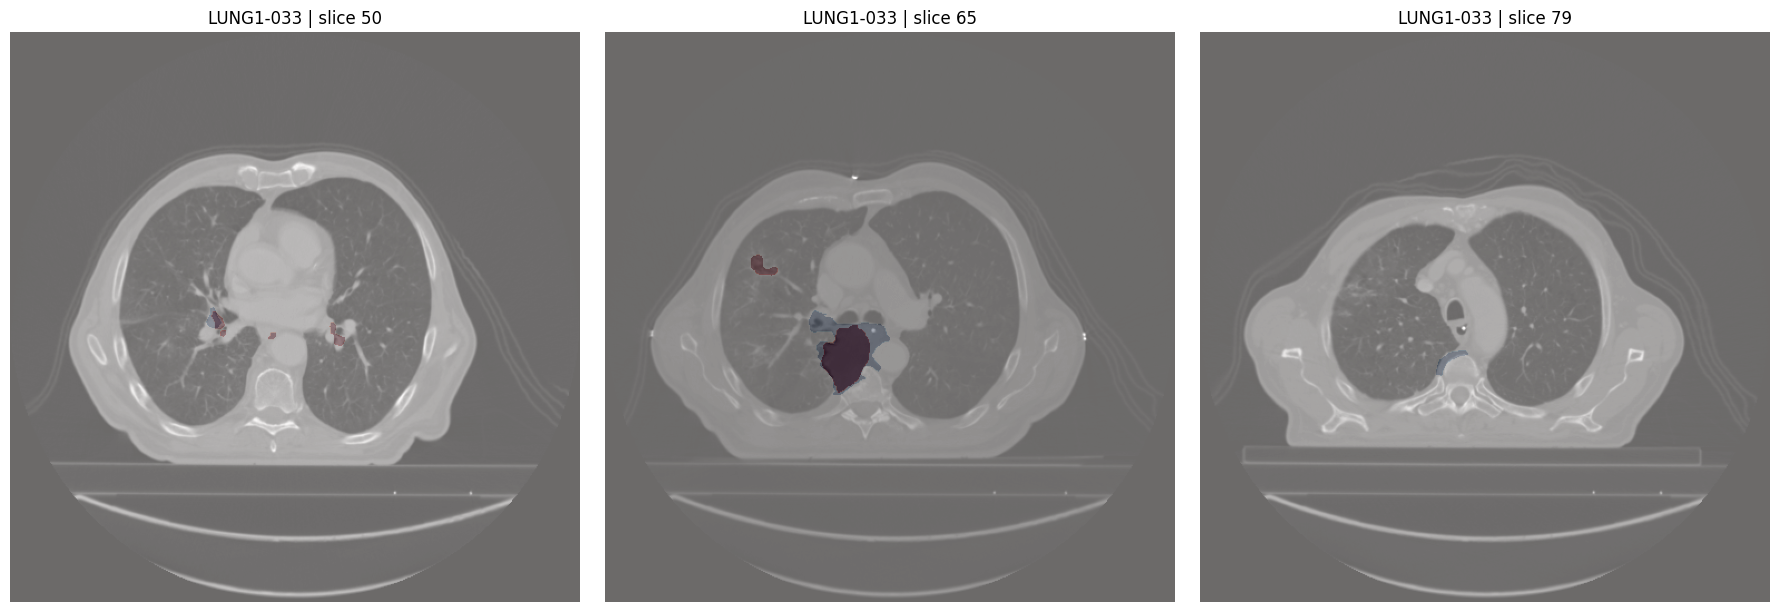

Worst case: LUNG1-050


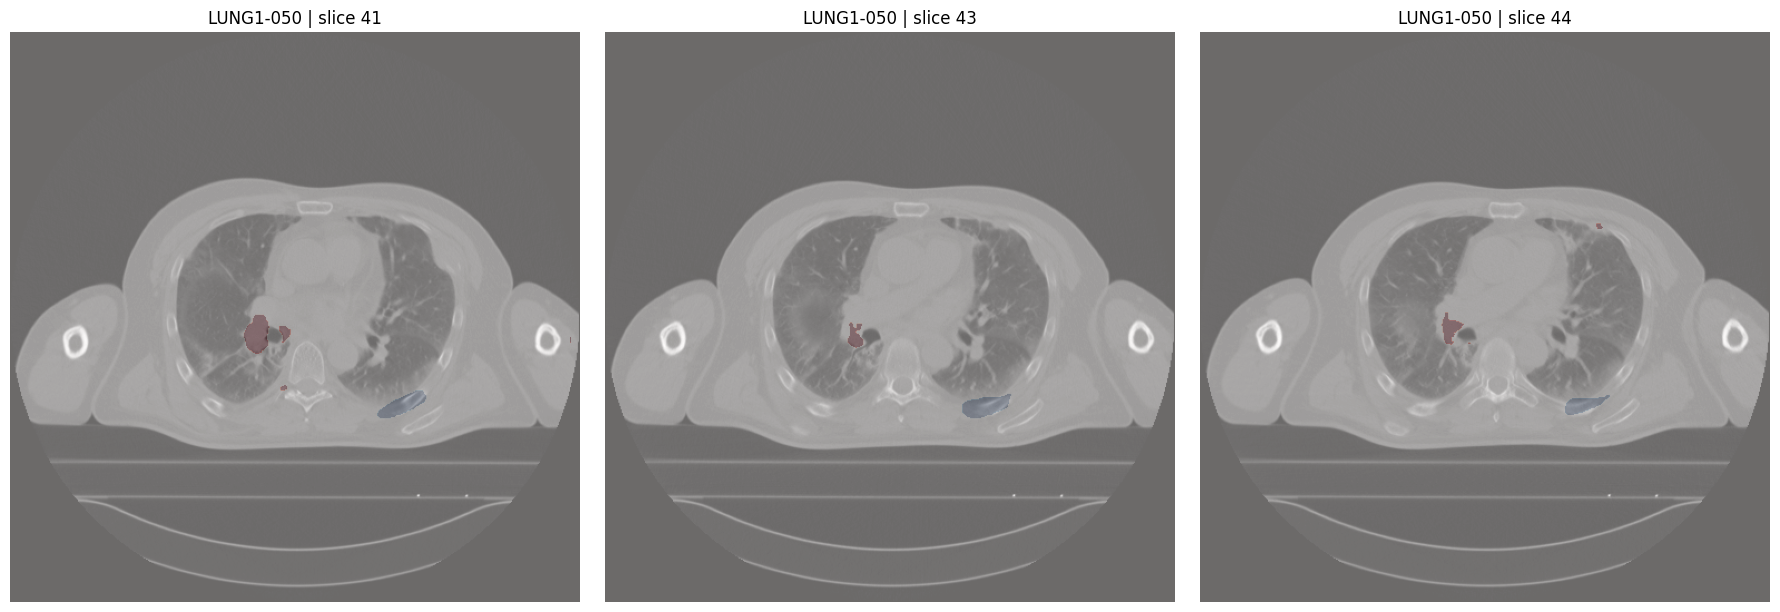

In [18]:
# ============================================================
# 16) VISUALIZE ONE BEST AND ONE WORST CASE
# ============================================================
if len(ok_df) > 0:
    best_case = ok_df.sort_values("dice", ascending=False).iloc[0]["patient_id"]
    worst_case = ok_df.sort_values("dice", ascending=True).iloc[0]["patient_id"]

    print("Best case:", best_case)
    visualize_nsclc_case(best_case, NSCLC_IMAGE_DIR, NSCLC_MASK_DIR, SAVE_PRED_DIR)

    print("Worst case:", worst_case)
    visualize_nsclc_case(worst_case, NSCLC_IMAGE_DIR, NSCLC_MASK_DIR, SAVE_PRED_DIR)